In [2]:
import keras
import tensorflow as tf
from keras import layers as tfkl
import numpy as np
import matplotlib.pyplot as plt
import os

print(tf.__version__)
print(keras.__version__)


2.10.0
2.10.0


# Loading a pre-trained model and MNIST dataset

In [30]:
# Constants
MODEL_PATH = 'vae_decoder_dim20.keras'
M = 200
N = 784
k = 32
index = 5
eta = 0.01
num_epochs = 500
tries = 3

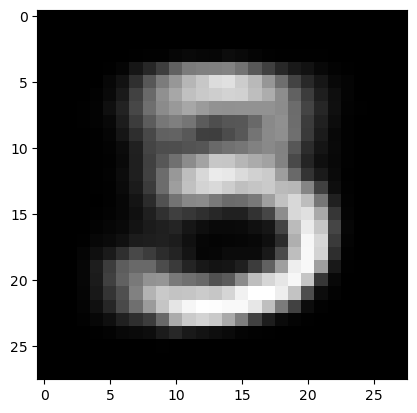

In [31]:
# Load NN model
G = keras.models.load_model(MODEL_PATH)
# Load chose dataset (MNIST)
(training_x,training_y) , (test_x , test_y) = tf.keras.datasets.mnist.load_data()
# Generate an image giving a random vectori in input to the NN to check the generatio capability
z = np.random.randn(1,20)
image = G(z)
plt.imshow(image[0,:,:,0],cmap='gray')

# Building a custom model using the pre-trained NN to minimize the error

In [32]:
# Ensure model layers are not trainable
G.trainable = True

for layer in G.layers:
    layer.trainable = False

# Generating the measurement matrix A
A = tf.constant(np.random.randn(M,N)* 1/M , shape=(M,N), dtype = tf.float32)
print(f'The shape of A is: {A.shape}')
# Generating the original image x_original
x_original = tf.constant(training_x[index,:,:].reshape(-1) , shape = (1,N), dtype = tf.float32)
print(f'The shape of x is: {x_original.shape}')
# Generating y
y = x_original @ tf.transpose(A) + tf.random.normal((1,M)) * eta
print(f'The shape of y is: {y.shape}')


The shape of A is: (200, 784)
The shape of x is: (1, 784)
The shape of y is: (1, 200)


In [33]:
# Define the loss function
def loss(z):
    Gz = G(z)
    Gz = Gz[0,:,:,0]
    Gz = tf.reshape(Gz, [1, 784])
    diff = tf.matmul(Gz,A , transpose_b=True) - y
    return tf.norm(diff)

# Optimization step
def train_step(z, optimizer):
    with tf.GradientTape() as tape:
        current_loss = loss(z)
    gradients = tape.gradient(current_loss, [z])
    optimizer.apply_gradients(zip(gradients, [z]))
    return current_loss

# Training loop
def train(num_epochs , tries , nn_input , A , y):
    best_loss = np.inf
    best_result = None
    for i in range(tries):
        z = tf.Variable(np.random.rand(1,nn_input), dtype = tf.float32)
        optimizer = tf.optimizers.Adam(learning_rate=0.01)
        for epoch in range(num_epochs):
            current_loss = train_step(z , optimizer)
            if epoch % 100 == 0:
                print(f'Epoch {epoch}, Loss: {current_loss.numpy()}')

        print(f'Optimized z has loss : {loss(z).numpy()}')
        if current_loss.numpy() < best_loss:
            best_loss = current_loss.numpy()
            best_result = z
    return best_loss , best_result

best_loss , z = train(num_epochs , tries , 20 , A , y)


Epoch 0, Loss: 163.13803100585938
Epoch 100, Loss: 163.08328247070312
Epoch 200, Loss: 163.07164001464844
Epoch 300, Loss: 163.0670928955078
Epoch 400, Loss: 163.06539916992188
Optimized z has loss : 163.06509399414062
Epoch 0, Loss: 163.2592315673828
Epoch 100, Loss: 163.1520538330078
Epoch 200, Loss: 163.1323699951172
Epoch 300, Loss: 163.119140625
Epoch 400, Loss: 163.09466552734375
Optimized z has loss : 163.08839416503906
Epoch 0, Loss: 163.21104431152344
Epoch 100, Loss: 163.08441162109375
Epoch 200, Loss: 163.07315063476562
Epoch 300, Loss: 163.068115234375
Epoch 400, Loss: 163.0659637451172
Optimized z has loss : 163.0647735595703


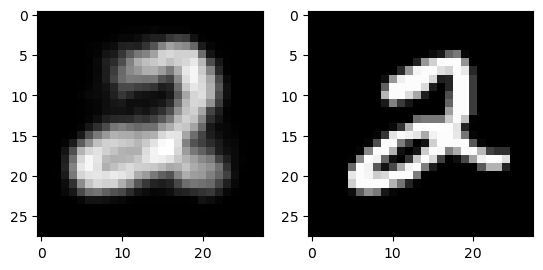

In [34]:
fig,axis = plt.subplots(1,2)
axis[0].imshow(G(z)[0,:,:,0], cmap='gray')
axis[1].imshow(training_x[index,:,:], cmap='gray')

# Reconstructing the image at various compression rates and checking the reconstruction error per pixel

In [60]:
losses = []
reconstructions = []
for M in range(20 , 784 , 50):
    A = tf.constant(np.random.randn(M,N)* 1/M , shape=(M,N), dtype = tf.float32)
    y = x_original @ tf.transpose(A) + tf.random.normal((1,M)) * eta
    best_loss , z = train(200 , 1 , 20 , A , y)
    print(f'For M = {M} , the best loss is {best_loss}')
    losses.append(best_loss)
    reconstructions.append(G(z)[0,:,:,0])

Epoch 0, Loss: 608.5675048828125
Epoch 100, Loss: 608.3556518554688
Optimized z has loss : 608.2572631835938
For M = 20 , the best loss is 608.2581176757812
Epoch 0, Loss: 322.86920166015625
Epoch 100, Loss: 322.7289123535156
Optimized z has loss : 322.6883544921875
For M = 70 , the best loss is 322.68865966796875
Epoch 0, Loss: 249.59347534179688
Epoch 100, Loss: 249.3711395263672
Optimized z has loss : 249.35482788085938
For M = 120 , the best loss is 249.3549346923828
Epoch 0, Loss: 186.48028564453125
Epoch 100, Loss: 186.44102478027344
Optimized z has loss : 186.4303741455078
For M = 170 , the best loss is 186.4304962158203
Epoch 0, Loss: 162.69357299804688
Epoch 100, Loss: 162.64080810546875
Optimized z has loss : 162.63174438476562
For M = 220 , the best loss is 162.63182067871094
Epoch 0, Loss: 157.2084197998047
Epoch 100, Loss: 157.1410675048828
Optimized z has loss : 157.13035583496094
For M = 270 , the best loss is 157.1304168701172
Epoch 0, Loss: 153.24423217773438
Epoch 100

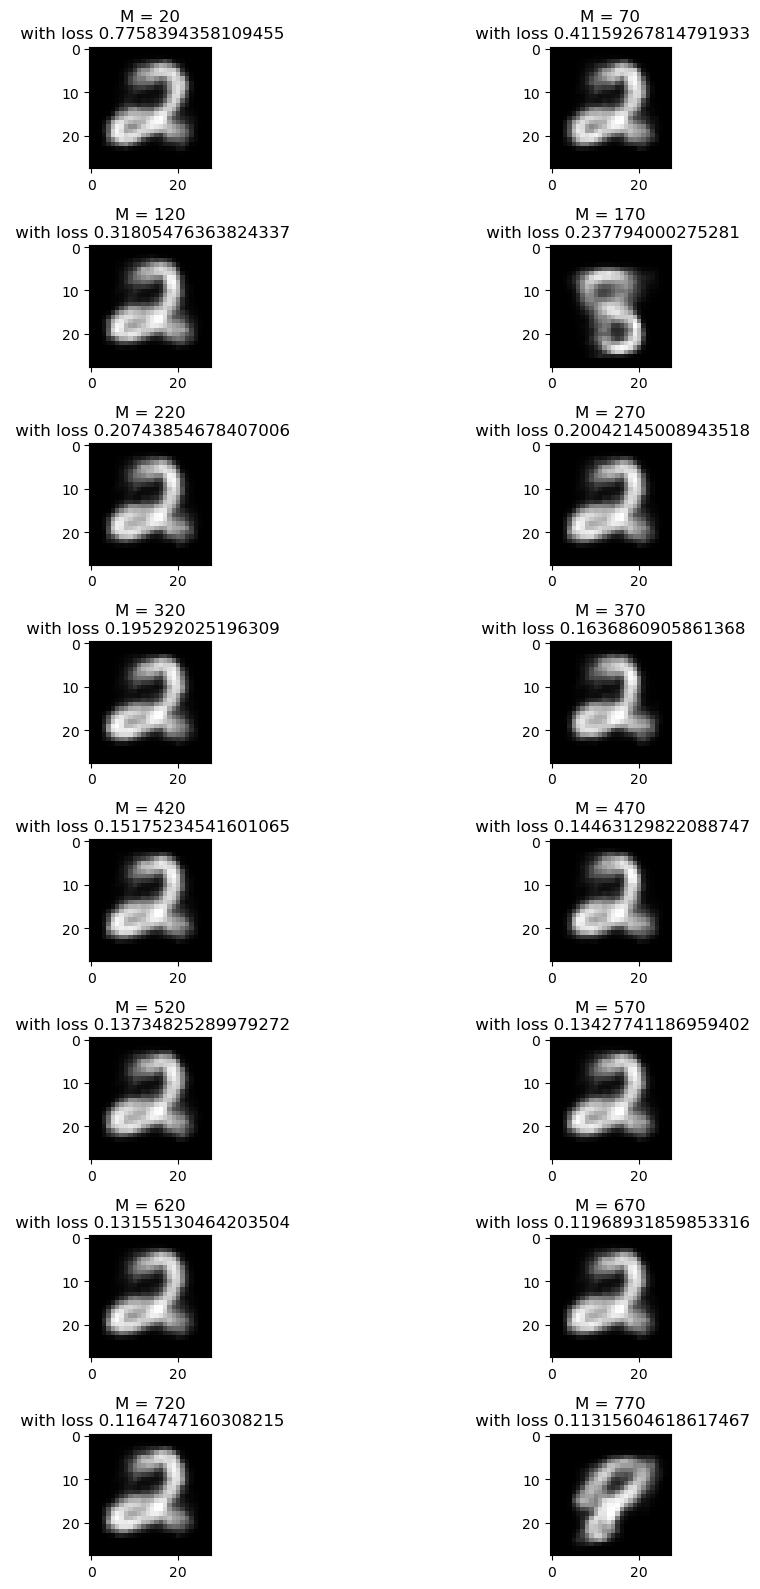

In [61]:
fig, axis = plt.subplots(8,2 , figsize = (12,16))
axis = axis.reshape((-1))
for i in range(len(reconstructions)):
    axis[i].imshow(reconstructions[i], cmap='gray')
    axis[i].set_title(f'M = {20 + i*50}\n with loss {losses[i]/784}')
fig.tight_layout()

Text(0.5, 1.0, 'Losses per pixel given M dimension of compressed sensing')

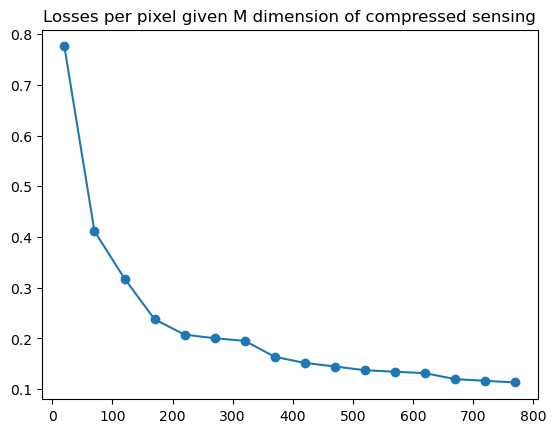

In [62]:
losses_norm = [loss / 784 for loss in losses]
plt.plot( range(20,784,50) , losses_norm, 'o-')
plt.title('Losses per pixel given M dimension of compressed sensing')